## Notebook Roadmap

This notebook is organized into the following parts:

1. Load and preview the dataset  
2. Clean and transform data for visualization  
3. Explore five analytical questions with static plots  
4. Build one interactive visualization  
5. Summarize key insights and connect them to the ML section

In [13]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional interactive libraries
import plotly.express as px
import plotly.graph_objects as go

# If using the Hugging Face dataset loader
from datasets import load_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 1. Load the Dataset

This project uses a BNPL dataset containing customer, transaction, provider, and repayment information.  
The visualizations in this notebook focus on variables such as:

- `principal_ngn`
- `credit_score`
- `provider`
- `merchant_category`
- `default_30d`
- `default_90d`
- `purchase_date`
- `first_payment_due`

In [14]:
# Load dataset
dataset = load_dataset("electricsheepafrica/nigerian-banking-bnpl")
df = dataset["train"].to_pandas()

print("Shape:", df.shape)
display(df.head())

Shape: (2000000, 16)


,transaction_id,purchase_date,customer_id,merchant_category,merchant_name,customer_state,principal_ngn,interest_rate_monthly,tenor_days,num_installments,provider,credit_score,first_time_customer,first_payment_due,default_30d,default_90d
0,BNPL-0000274330,2024-07-10,CUS-00036437,groceries,Groceries Store 105,Oyo,35416.989135,0.000000,14,1,FairMoney,645,False,2024-08-09,False,False
1,BNPL-0001873807,2023-08-01,CUS-00131005,furniture,Furniture Store 820,Lagos,43154.846706,0.000000,30,1,FairMoney,716,True,2023-08-31,False,False
2,BNPL-0001029126,2022-02-12,CUS-00648656,electronics,Electronics Store 346,Abuja (FCT),247235.615112,0.000000,14,1,Branch,470,False,2022-03-14,False,False
3,BNPL-0001512791,2023-01-26,CUS-00611557,furniture,Furniture Store 393,Lagos,70679.217230,0.032728,30,1,Branch,620,False,2023-02-25,False,False
4,BNPL-0000552055,2023-01-12,CUS-00499951,fashion,Fashion Store 956,Ekiti,225083.504313,0.049655,90,3,Branch,536,False,2023-02-11,False,False


In [15]:
# Quick structure check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         object        
 1   purchase_date          datetime64[ns]
 2   customer_id            object        
 3   merchant_category      object        
 4   merchant_name          object        
 5   customer_state         object        
 6   principal_ngn          float64       
 7   interest_rate_monthly  float64       
 8   tenor_days             int64         
 9   num_installments       int64         
 10  provider               object        
 11  credit_score           int64         
 12  first_time_customer    bool          
 13  first_payment_due      datetime64[ns]
 14  default_30d            bool          
 15  default_90d            bool          
dtypes: bool(3), datetime64[ns](2), float64(2), int64(3), object(6)
memory usage: 204.1+ MB


In [16]:
# Missing values overview
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

,0


## 2. Data Cleaning and Transformation for Visualization

This section prepares the dataset for plotting.  
We only include transformations that are useful for the visualization portion of the project.

In [17]:
# Make a working copy
viz_df = df.copy()

# Convert date columns if present
date_cols = ["purchase_date", "first_payment_due"]
for col in date_cols:
    if col in viz_df.columns:
        viz_df[col] = pd.to_datetime(viz_df[col], errors="coerce")

# Convert target columns to numeric if needed
for col in ["default_30d", "default_90d", "credit_score", "principal_ngn", "annual_income_ngn"]:
    if col in viz_df.columns:
        viz_df[col] = pd.to_numeric(viz_df[col], errors="coerce")

viz_df.head()

,transaction_id,purchase_date,customer_id,merchant_category,merchant_name,customer_state,principal_ngn,interest_rate_monthly,tenor_days,num_installments,provider,credit_score,first_time_customer,first_payment_due,default_30d,default_90d
0,BNPL-0000274330,2024-07-10,CUS-00036437,groceries,Groceries Store 105,Oyo,35416.989135,0.000000,14,1,FairMoney,645,False,2024-08-09,False,False
1,BNPL-0001873807,2023-08-01,CUS-00131005,furniture,Furniture Store 820,Lagos,43154.846706,0.000000,30,1,FairMoney,716,True,2023-08-31,False,False
2,BNPL-0001029126,2022-02-12,CUS-00648656,electronics,Electronics Store 346,Abuja (FCT),247235.615112,0.000000,14,1,Branch,470,False,2022-03-14,False,False
3,BNPL-0001512791,2023-01-26,CUS-00611557,furniture,Furniture Store 393,Lagos,70679.217230,0.032728,30,1,Branch,620,False,2023-02-25,False,False
4,BNPL-0000552055,2023-01-12,CUS-00499951,fashion,Fashion Store 956,Ekiti,225083.504313,0.049655,90,3,Branch,536,False,2023-02-11,False,False


In [18]:
# Create credit score tiers
def credit_tier(score):
    if pd.isna(score):
        return np.nan
    if score < 580:
        return "Terrible"
    elif score < 670:
        return "Bad"
    elif score < 740:
        return "Decent"
    else:
        return "Good"

viz_df["credit_tier"] = viz_df["credit_score"].apply(credit_tier)

# Add a few time-based columns if purchase_date exists
if "purchase_date" in viz_df.columns:
    viz_df["purchase_month"] = viz_df["purchase_date"].dt.month
    viz_df["purchase_dayofweek"] = viz_df["purchase_date"].dt.day_name()

viz_df[["credit_score", "credit_tier"]].head()

,credit_score,credit_tier
0,645,Bad
1,716,Decent
2,470,Terrible
3,620,Bad
4,536,Terrible


## 3. Static Visualizations

Each section below includes:
- the analytical question
- the plot used
- a short interpretation

You can revise the markdown to match the exact wording your team wants in the final combined notebook.

## Question 1  
### Do first-time customers make different-sized purchases than returning customers?

This question compares the distribution of purchase amounts between first-time customers and returning customers

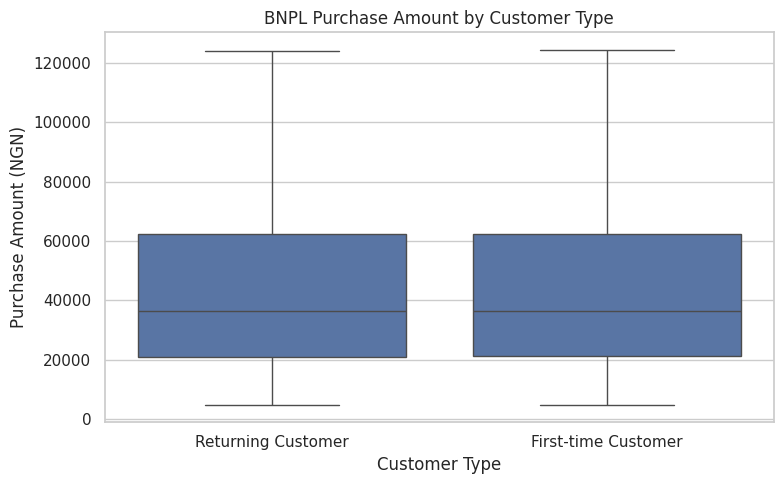

,count,mean,std,min,25%,50%,75%,max
customer_type,,,,,,,,
First-time Customer,799952.0,50023.709988,46524.005040,5000.0,21188.621237,36349.215928,62405.849256,500000.0
Returning Customer,1200048.0,49947.545238,46539.324707,5000.0,21134.915255,36294.843101,62246.908580,500000.0


In [19]:
q1_df = viz_df[["first_time_customer", "principal_ngn"]].dropna().copy()

# Make labels easier to read
q1_df["customer_type"] = q1_df["first_time_customer"].map({
    True: "First-time Customer",
    False: "Returning Customer"
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=q1_df, x="customer_type", y="principal_ngn", showfliers=False)
plt.title("BNPL Purchase Amount by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Purchase Amount (NGN)")
plt.tight_layout()
plt.show()

display(
    q1_df.groupby("customer_type")["principal_ngn"].describe()
)

**Summary of analysis:**  
The plot showed that the two groups have fairly similar purchase amount distributions overall. However, first-time customers appear to have a slightly higher median purchase amount than returning customers. Both groups also contain many large outliers, which suggests that unusually high-value purchases occur in both customer types. Overall, customer type may have some relationship with transaction size, but the difference does not appear to be very large from this visualization alone.

## Question 2  
### Do customers of different BNPL providers show different repayment behavior across credit score tiers?

This question compares provider-level 30-day default rates across credit score groups.

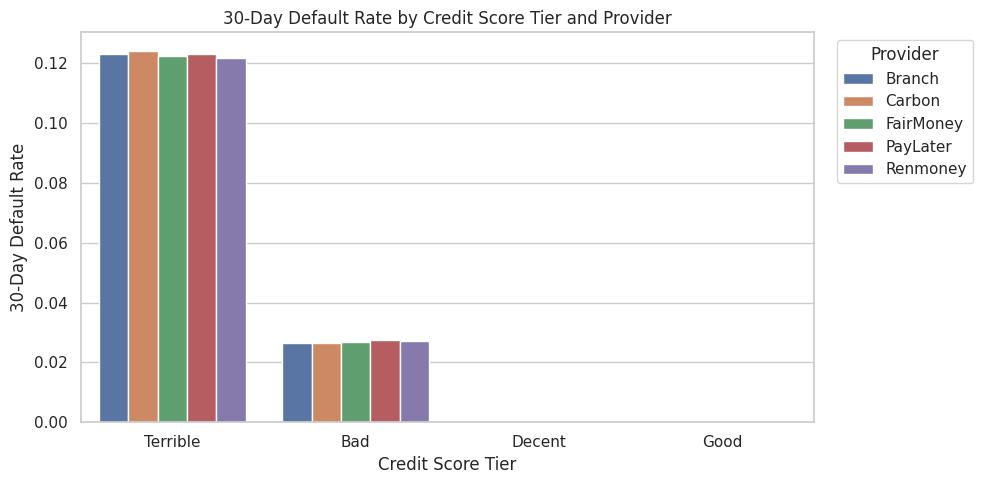

,credit_tier,provider,default_30d
15,Terrible,Branch,0.123158
16,Terrible,Carbon,0.124135
17,Terrible,FairMoney,0.122574
18,Terrible,PayLater,0.122985
19,Terrible,Renmoney,0.121889
0,Bad,Branch,0.026468
1,Bad,Carbon,0.026620
2,Bad,FairMoney,0.026709
3,Bad,PayLater,0.027633
4,Bad,Renmoney,0.027132


In [20]:
# 30-day default rate by credit score tier and provider
q2_df = viz_df.dropna(subset=["credit_tier", "provider", "default_30d"]).copy()
q2_grouped = (
    q2_df.groupby(["credit_tier", "provider"], as_index=False, observed=True)["default_30d"]
    .mean()
)

tier_order = ["Terrible", "Bad", "Decent", "Good"]
q2_grouped["credit_tier"] = pd.Categorical(q2_grouped["credit_tier"], categories=tier_order, ordered=True)
q2_grouped = q2_grouped.sort_values(["credit_tier", "provider"])

plt.figure(figsize=(10, 5))
sns.barplot(data=q2_grouped, x="credit_tier", y="default_30d", hue="provider")
plt.title("30-Day Default Rate by Credit Score Tier and Provider")
plt.xlabel("Credit Score Tier")
plt.ylabel("30-Day Default Rate")
plt.legend(title="Provider", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(q2_grouped.head(12))


**Summary of analysis:**  
This bar chart compares 30-day default rates across BNPL providers within each credit score tier. The clearest pattern is that customers in the Terrible credit tier have much higher default rates than those in the Bad tier, while the Decent and Good tiers show little to no visible default activity here. Overall, this suggests that credit score tier has a much stronger relationship with short-term default risk than provider.

## Question 3  
### How does the 90-day default rate change based on credit score and provider?

This question extends the repayment analysis by looking at longer-term default behavior.

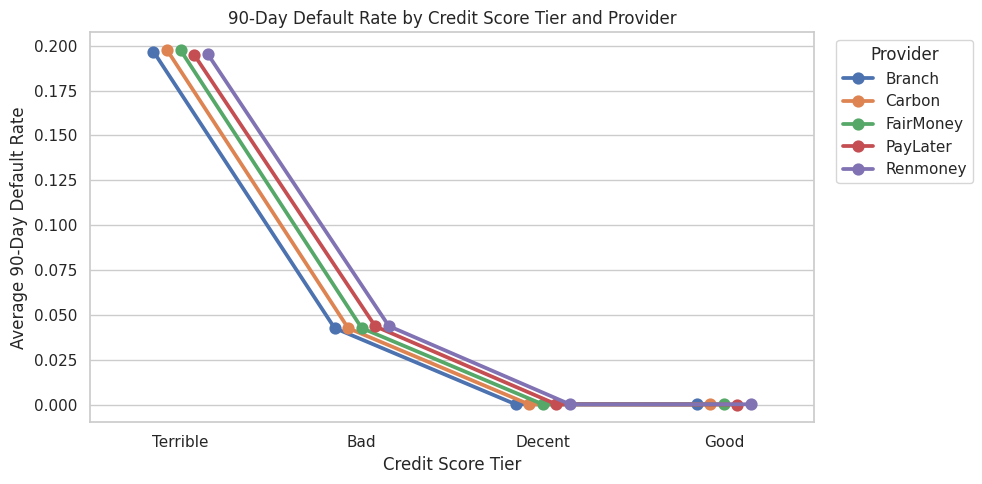

,credit_score_bin,provider,default_90d
0,Terrible,Branch,0.196725
1,Terrible,Carbon,0.197589
2,Terrible,FairMoney,0.197438
3,Terrible,PayLater,0.194895
4,Terrible,Renmoney,0.195294
5,Bad,Branch,0.042685
6,Bad,Carbon,0.042637
7,Bad,FairMoney,0.042668
8,Bad,PayLater,0.043636
9,Bad,Renmoney,0.043773


In [21]:
# Create credit score bins for a cleaner 90-day default visualization
q3_df = viz_df.dropna(subset=["credit_score", "provider", "default_90d"]).copy()

q3_df["credit_score_bin"] = pd.cut(
    q3_df["credit_score"],
    bins=[300, 579, 669, 739, 850],
    labels=["Terrible", "Bad", "Decent", "Good"]
)

q3_grouped = (
    q3_df.groupby(["credit_score_bin", "provider"], as_index=False, observed=True)["default_90d"]
    .mean()
)

plt.figure(figsize=(10, 5))
sns.pointplot(
    data=q3_grouped,
    x="credit_score_bin",
    y="default_90d",
    hue="provider",
    dodge=0.3
)
plt.title("90-Day Default Rate by Credit Score Tier and Provider")
plt.xlabel("Credit Score Tier")
plt.ylabel("Average 90-Day Default Rate")
plt.legend(title="Provider", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(q3_grouped.head(12))

**Summary of analysis:**  
This plot shows that 90-day default rates decrease sharply as credit score tier improves. Customers in the Terrible tier have the highest default rates, the Bad tier is greatly lower, and the Decent and Good tiers are close to zero. The provider lines follow almost the same pattern, which means the differences across providers are relatively small compared to the effect of credit score. Overall, this suggests that credit score tier is a much stronger indicator of long-term default risk than provider.

## Question 4  
### Do customers with different credit scores behave differently?

This question looks at whether purchase behavior changes across credit score tiers.

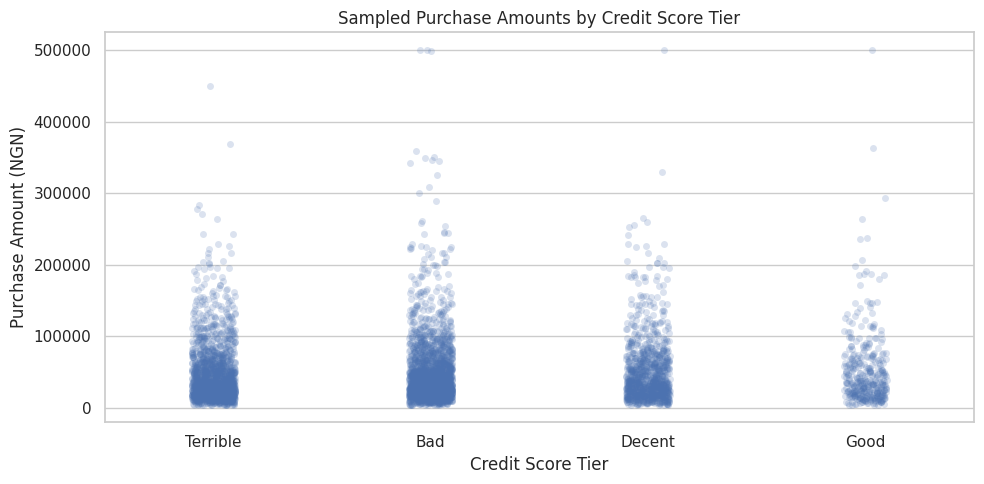

In [22]:
q4_df = viz_df.dropna(subset=["credit_score", "principal_ngn"]).copy()

q4_df["credit_tier"] = pd.cut(
    q4_df["credit_score"],
    bins=[300, 579, 669, 739, 850],
    labels=["Terrible", "Bad", "Decent", "Good"]
)

sample_q4 = q4_df.sample(5000, random_state=42)

plt.figure(figsize=(10, 5))
sns.stripplot(data=sample_q4, x="credit_tier", y="principal_ngn", alpha=0.2, jitter=True)
plt.title("Sampled Purchase Amounts by Credit Score Tier")
plt.xlabel("Credit Score Tier")
plt.ylabel("Purchase Amount (NGN)")
plt.tight_layout()
plt.show()

**Summary of analysis:**  
This plot suggests that purchase amounts are fairly spread out across all credit score tiers, with substantial overlap between the groups. Most transactions in every tier are concentrated at lower purchase amounts, while each tier also includes some much larger purchases. The Bad tier appears to show a somewhat wider spread and more high-value transactions in this sample, but the overall differences across tiers are not very strong. This suggests that credit score tier may have some relationship with purchase amount, but it does not clearly separate spending behavior on its own.


## Question 5  
### Do different purchase categories have different spending patterns?

This question compares spending behavior across merchant or purchase categories.

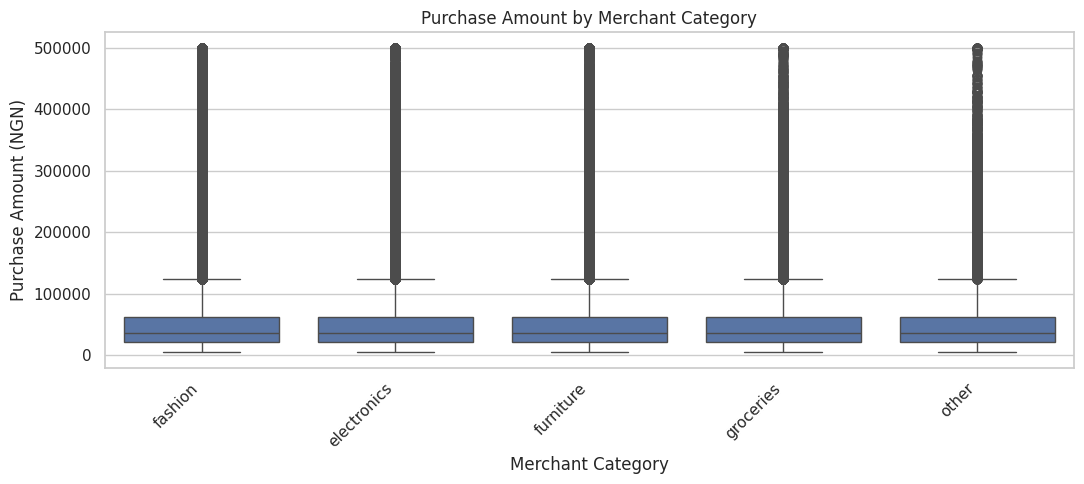

,merchant_category,principal_ngn
0,groceries,35416.989135
1,furniture,43154.846706
2,electronics,247235.615112
3,furniture,70679.217230
4,fashion,225083.504313


In [23]:
# Category-level spending patterns
category_col = None
for candidate in ["merchant_category", "purchase_category", "category"]:
    if candidate in viz_df.columns:
        category_col = candidate
        break

if category_col is None:
    print("No category column found. Replace 'category_col' with the correct column name before running this section.")
else:
    q5_df = viz_df.dropna(subset=[category_col, "principal_ngn"]).copy()

    category_order = (
        q5_df.groupby(category_col)["principal_ngn"]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(11, 5))
    sns.boxplot(data=q5_df, x=category_col, y="principal_ngn", order=category_order)
    plt.title("Purchase Amount by Merchant Category")
    plt.xlabel("Merchant Category")
    plt.ylabel("Purchase Amount (NGN)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

viz_df[[category_col, "principal_ngn"]].head()

**Summary of analysis:**  
This boxplot suggests that purchase amount distributions are fairly similar across the merchant categories in our dataset. The median purchase amounts and the main spread of the data look similar across categories, which means no single category stands out as having dramatically different spending patterns. At the same time, every category includes many large outliers, showing that high-value purchases occur across all types of merchants. Overall, merchant category may have some influence on spending patterns, but the differences appear modest rather than extreme.


## 4. Interactive Component

This section includes an interactive visualization that lets the user examine provider-level repayment patterns more flexibly than a static chart.

In [24]:
# Interactive plot with Plotly
interactive_df = viz_df.dropna(subset=["provider", "credit_tier", "default_30d"]).copy()

interactive_grouped = (
    interactive_df.groupby(["provider", "credit_tier"], as_index=False)["default_30d"]
    .mean()
)

fig = px.bar(
    interactive_grouped,
    x="credit_tier",
    y="default_30d",
    color="provider",
    barmode="group",
    title="Interactive: 30-Day Default Rate by Credit Score Tier and Provider",
    category_orders={"credit_tier": ["Terrible", "Bad", "Decent", "Good"]},
    labels={"default_30d": "Average 30-Day Default Rate", "credit_tier": "Credit Score Tier"}
)

fig.show()

### How to Use the Interactive Visualization

- Run all notebook cells from top to bottom  
- Make sure required packages are installed: `pandas`, `matplotlib`, `seaborn`, `plotly`, and `datasets`  
- Run the interactive plot cell  
- Hover over the bars to inspect values for each provider and credit tier

## 5. Key Visualization Insights

Across the five questions, several patterns appeared consistently. Credit score showed the clearest relationship with repayment behavior: lower credit tiers had much higher 30-day and 90-day default rates, while higher tiers had very low default rates. Provider-level differences were visible, but they were generally much smaller than the effect of credit score. We also found that purchase amounts varied somewhat by customer type, credit tier, and merchant category, which suggests that spending behavior is shaped by more than one factor.

Taken together, these visualizations show that both risk-related variables and transaction-related variables matter in this dataset. Credit score and repayment outcomes tell us about customer risk, while purchase amount, merchant category, and customer status help describe borrowing behavior. The interactive chart adds another layer by making it easier to compare providers within each credit tier.


## 6. Connection to the Machine Learning Section

The visualizations in this notebook help identify which variables are most promising for the later machine learning pipeline. Credit score was the strongest and most consistent signal in both the 30-day and 90-day default plots, which suggests it should be an important predictor in any default model. Provider showed smaller but still noticeable differences, so it may still add value when combined with other features. In addition, purchase amount, merchant category, and first-time customer status all showed some variation in borrowing behavior, which means they may also help explain repayment outcomes.

These findings support the machine learning section of the project by motivating both the feature choices and the prediction tasks. Since the team is modeling repayment outcomes such as `default_30d` and `default_90d`, classification models are a natural fit. More broadly, the visualization section does not just describe the data—it helps justify why variables like `credit_score`, `provider`, `principal_ngn`, `merchant_category`, and customer history are useful inputs for model training and evaluation.
